In [2]:
import pandas as pd

In [5]:
data = pd.read_csv(
    r"C:\Users\M BINDU\Desktop\PowerCast\data\household_power_consumption.txt",
    sep=";",
    low_memory=False
)

data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [6]:
data.shape

(2075259, 9)

In [7]:
data.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [8]:
data.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [9]:
data.replace('?', None, inplace=True)

In [10]:
data['Global_active_power'] = pd.to_numeric(
    data['Global_active_power'], errors='coerce'
)

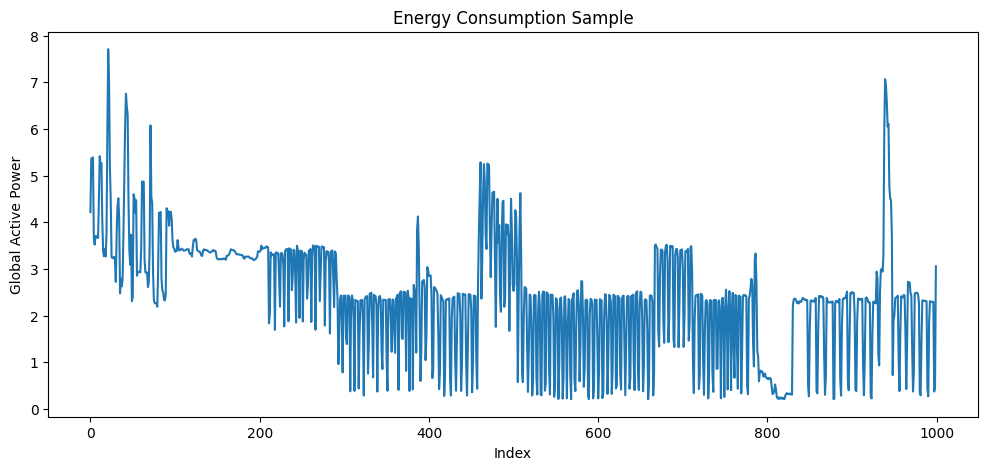

In [11]:
import matplotlib.pyplot as plt

data['Global_active_power'].head(1000).plot(figsize=(12,5))

plt.title("Energy Consumption Sample")
plt.xlabel("Index")
plt.ylabel("Global Active Power")
plt.show()

In [12]:
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

C:\Users\M BINDU\AppData\Local\Temp\ipykernel_15260\257169346.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])


In [13]:
data[['Date', 'Time', 'Datetime']].head()

,Date,Time,Datetime
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


In [14]:
data.set_index('Datetime', inplace=True)

In [15]:
data.drop(['Date', 'Time'], axis=1, inplace=True)

In [16]:
data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


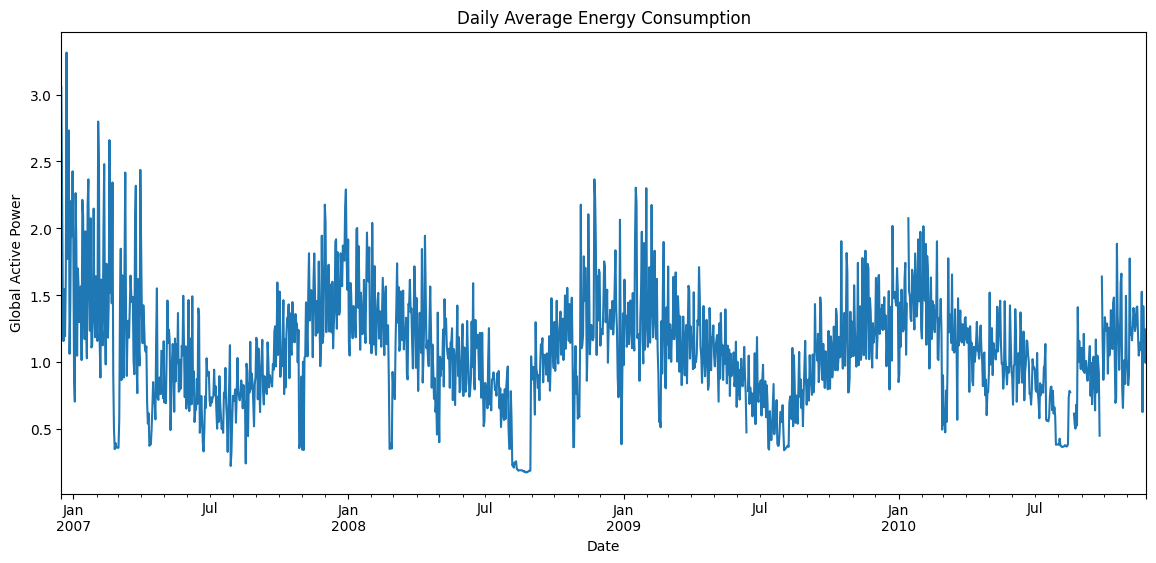

In [17]:
data['Global_active_power'].resample('D').mean().plot(figsize=(14,6))
plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.show()

In [18]:
data['lag_1'] = data['Global_active_power'].shift(1)
data['lag_2'] = data['Global_active_power'].shift(2)
data['lag_3'] = data['Global_active_power'].shift(3)

In [19]:
data[['Global_active_power','lag_1','lag_2','lag_3']].head()

,Global_active_power,lag_1,lag_2,lag_3
Datetime,,,,
2006-12-16 17:24:00,4.216,NaN,NaN,NaN
2006-12-16 17:25:00,5.360,4.216,NaN,NaN
2006-12-16 17:26:00,5.374,5.360,4.216,NaN
2006-12-16 17:27:00,5.388,5.374,5.360,4.216
2006-12-16 17:28:00,3.666,5.388,5.374,5.360


In [20]:
data.dropna(inplace=True)

In [21]:
X = data[['lag_1','lag_2','lag_3']]
y = data['Global_active_power']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
predictions = model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.0837977496320307


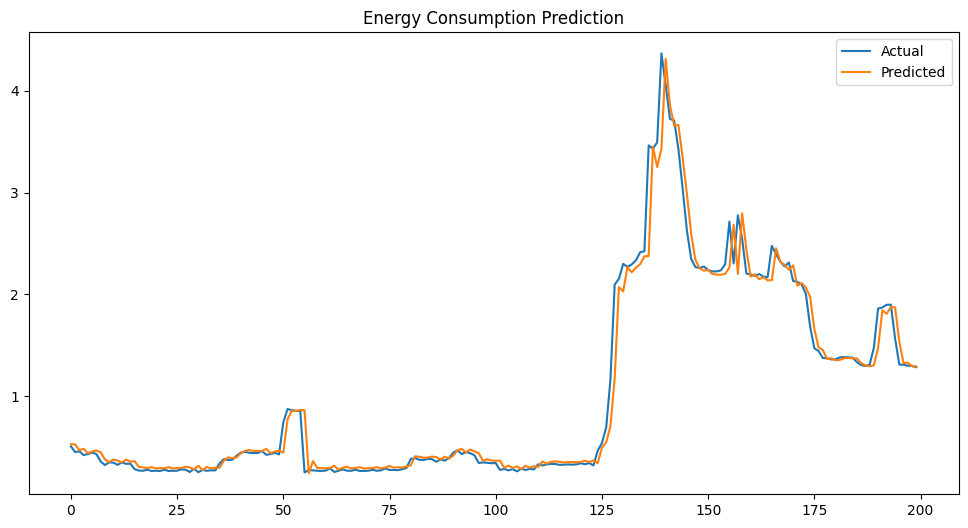

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")

plt.legend()
plt.title("Energy Consumption Prediction")
plt.show()

In [28]:
data['hour'] = data.index.hour
data['day'] = data.index.day
data['month'] = data.index.month
data['day_of_week'] = data.index.dayofweek

In [29]:
data[['hour','day','month','day_of_week']].head()

,hour,day,month,day_of_week
Datetime,,,,
2006-12-16 17:27:00,17,16,12,5
2006-12-16 17:28:00,17,16,12,5
2006-12-16 17:29:00,17,16,12,5
2006-12-16 17:30:00,17,16,12,5
2006-12-16 17:31:00,17,16,12,5


In [30]:
X = data[['lag_1','lag_2','lag_3','hour','day','month','day_of_week']]
y = data['Global_active_power']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("New MAE:", mae)

New MAE: 0.0841828027971899


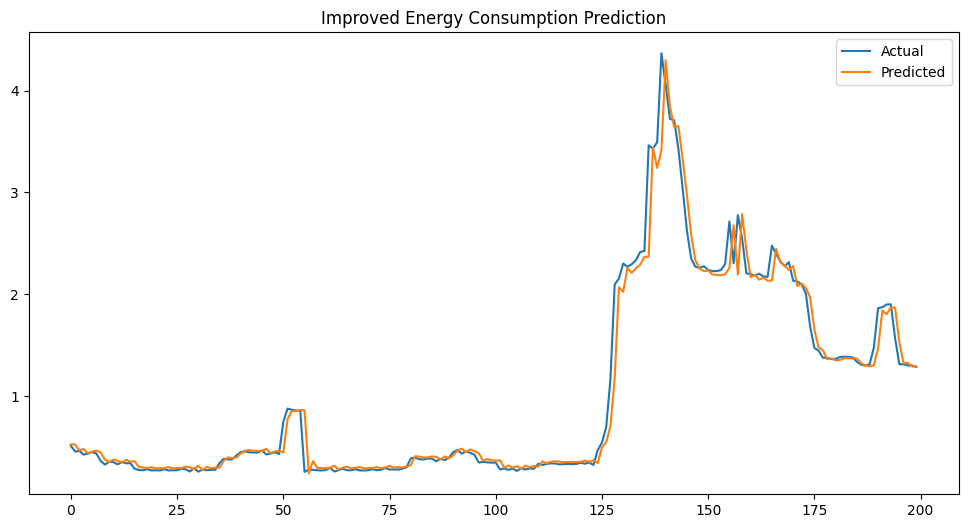

In [33]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")

plt.legend()
plt.title("Improved Energy Consumption Prediction")
plt.show()

In [34]:
from statsmodels.tsa.arima.model import ARIMA

In [35]:
ts_data = data['Global_active_power'].resample('H').mean()
ts_data = ts_data.dropna()
ts_data.head()

C:\Users\M BINDU\AppData\Local\Temp\ipykernel_15260\1864704976.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts_data = data['Global_active_power'].resample('H').mean()


Datetime
2006-12-16 17:00:00    4.153758
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Name: Global_active_power, dtype: float64

In [36]:
model_arima = ARIMA(ts_data, order=(5,1,0))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

c:\Users\M BINDU\Desktop\PowerCast\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\M BINDU\Desktop\PowerCast\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\M BINDU\Desktop\PowerCast\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                34167
Model:                  ARIMA(5, 1, 0)   Log Likelihood              -34320.402
Date:                 Wed, 11 Mar 2026   AIC                          68652.803
Time:                         16:31:01   BIC                          68703.437
Sample:                              0   HQIC                         68668.950
                               - 34167                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1121      0.004    -27.350      0.000      -0.120      -0.104
ar.L2         -0.1607      0.005    -34.807      0.000      -0.170      -0.152
ar.L3         -0.1216      0.005    -24.598 

In [37]:
forecast = model_arima_fit.forecast(steps=24)
forecast

c:\Users\M BINDU\Desktop\PowerCast\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\M BINDU\Desktop\PowerCast\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


34167    0.975940
34168    1.074207
34169    1.139372
34170    1.196413
34171    1.187791
34172    1.154265
34173    1.133017
34174    1.127131
34175    1.130037
34176    1.138569
34177    1.144371
34178    1.145135
34179    1.143358
34180    1.141294
34181    1.140010
34182    1.139954
34183    1.140564
34184    1.141128
34185    1.141371
34186    1.141329
34187    1.141153
34188    1.141009
34189    1.140964
34190    1.140991
Name: predicted_mean, dtype: float64

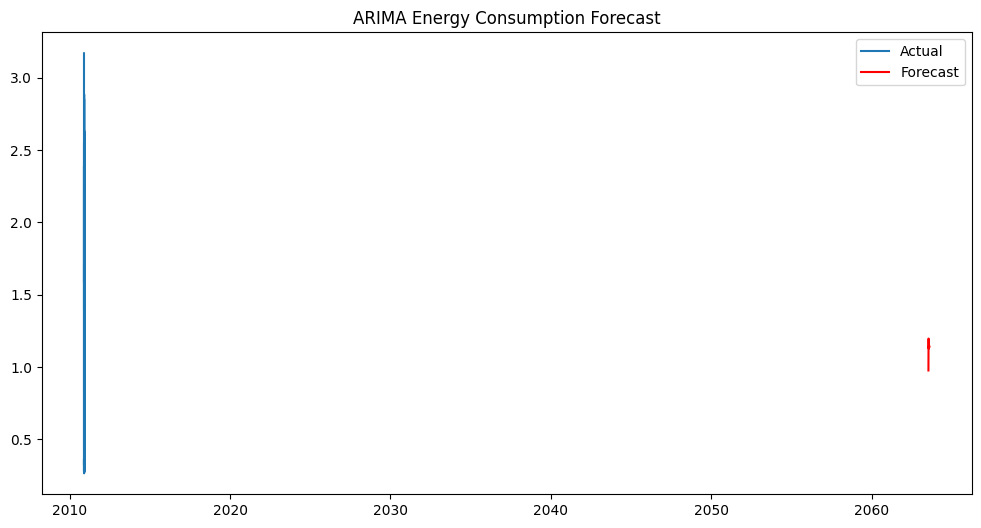

In [38]:
plt.figure(figsize=(12,6))

plt.plot(ts_data[-100:], label="Actual")
plt.plot(forecast, label="Forecast", color="red")

plt.legend()
plt.title("ARIMA Energy Consumption Forecast")
plt.show()

In [39]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [40]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    ts_data.values.reshape(-1,1)
)

In [41]:
sequence_length = 24

X_lstm = []
y_lstm = []

for i in range(sequence_length, len(scaled_data)):
    X_lstm.append(scaled_data[i-sequence_length:i])
    y_lstm.append(scaled_data[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

In [42]:
split = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]

In [43]:
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1],1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [44]:
history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=32
)

Epoch 1/5

854/854 [==============================] - 18s 19ms/step - loss: 0.0117
Epoch 2/5
854/854 [==============================] - 14s 17ms/step - loss: 0.0092
Epoch 3/5
854/854 [==============================] - 12s 14ms/step - loss: 0.0089
Epoch 4/5
854/854 [==============================] - 19s 22ms/step - loss: 0.0088
Epoch 5/5
854/854 [==============================] - 23s 27ms/step - loss: 0.0087


In [45]:
predictions_lstm = model_lstm.predict(X_test_lstm)

predictions_lstm = scaler.inverse_transform(predictions_lstm)

214/214 [==============================] - 2s 5ms/step


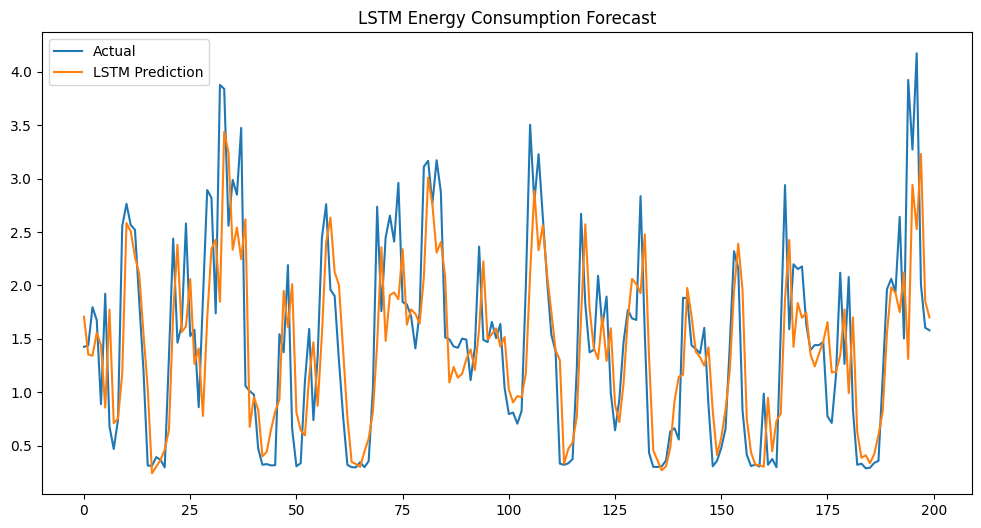

In [46]:
plt.figure(figsize=(12,6))

actual = scaler.inverse_transform(y_test_lstm)

plt.plot(actual[:200], label="Actual")
plt.plot(predictions_lstm[:200], label="LSTM Prediction")

plt.legend()
plt.title("LSTM Energy Consumption Forecast")
plt.show()